# Importing libraries

In [25]:
from pathlib import Path
import requests 
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# Paths based on structure
PROJECT_DIR = Path("..")
REF_DIR = PROJECT_DIR / "data" / "reference"

REF_DIR.mkdir(parents=True, exist_ok=True)

# Time zone setting and weather feature extraction

In [26]:
# Setting the location of Mexico City as well as the time zone
lat = 19.4326
lon = -99.1332

start_date = "2018-01-01"
end_date = "2025-12-31"

timezone = "America/Mexico_City"

In [27]:
# Call on the Open Meteo API
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": lat,
    "longitude": lon,
    "start_date": start_date,
    "end_date": end_date,
    "hourly": "temperature_2m,precipitation",
    "timezone": timezone,
}

response = requests.get(url, params=params, timeout=60)
response.raise_for_status()

weather_json = response.json()
weather_json.keys()

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])

In [28]:
# Convert to dataframe and check head
weather_raw = pd.DataFrame(weather_json["hourly"])

print(weather_raw.shape)
weather_raw.head()

(70128, 3)


,time,temperature_2m,precipitation
0,2018-01-01T00:00,13.2,0.0
1,2018-01-01T01:00,12.1,0.0
2,2018-01-01T02:00,11.0,0.0
3,2018-01-01T03:00,10.1,0.0
4,2018-01-01T04:00,9.2,0.0


# Datetime hour standardization

In [29]:
# Standardizing datetime_hour for parquet
weather = weather_raw.copy()

weather["datetime_hour"] = pd.to_datetime(weather["time"])
if weather["datetime_hour"].dt.tz is not None:
    weather["datetime_hour"] = weather["datetime_hour"].dt.tz_localize(None)

weather["datetime_hour"] = weather["datetime_hour"].dt.floor("h")

weather = weather.rename(columns={
    "temperature_2m": "temperature",
    "precipitation": "rain"
})

weather = weather[
    ["datetime_hour", "temperature", "rain"]
].copy()

weather.head()

,datetime_hour,temperature,rain
0,2018-01-01 00:00:00,13.2,0.0
1,2018-01-01 01:00:00,12.1,0.0
2,2018-01-01 02:00:00,11.0,0.0
3,2018-01-01 03:00:00,10.1,0.0
4,2018-01-01 04:00:00,9.2,0.0


# Summary statistics

In [30]:
# Basic stats
print("Shape:", weather.shape)
print("Min datetime:", weather["datetime_hour"].min())
print("Max datetime:", weather["datetime_hour"].max())

weather[["temperature", "rain"]].describe()

Shape: (70128, 3)
Min datetime: 2018-01-01 00:00:00
Max datetime: 2025-12-31 23:00:00


,temperature,rain
count,70128.000000,70128.000000
mean,17.166764,0.130175
std,5.219916,0.608321
min,0.300000,0.000000
25%,13.600000,0.000000
50%,16.500000,0.000000
75%,21.000000,0.000000
max,34.200000,12.600000


In [31]:
# Checking there's 1h per row, no missing
expected_hours = pd.date_range(
    start_date,
    end_date + " 23:00:00",
    freq="h"
)

print("Expected hours:", len(expected_hours))
print("Observed hours:", len(weather))
print("Missing hourly timestamps:", len(set(expected_hours) - set(weather["datetime_hour"])))

Expected hours: 70128
Observed hours: 70128
Missing hourly timestamps: 0


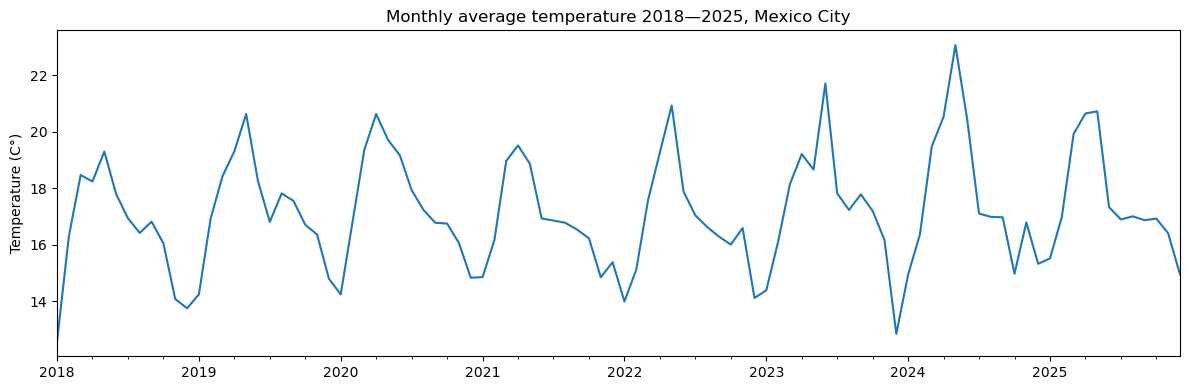

In [32]:
weather.set_index("datetime_hour")["temperature"].resample("ME").mean().plot(figsize=(12, 4))
plt.title("Monthly average temperature 2018—2025, Mexico City")
plt.ylabel("Temperature (C°)")
plt.xlabel("")
plt.tight_layout()
plt.show()

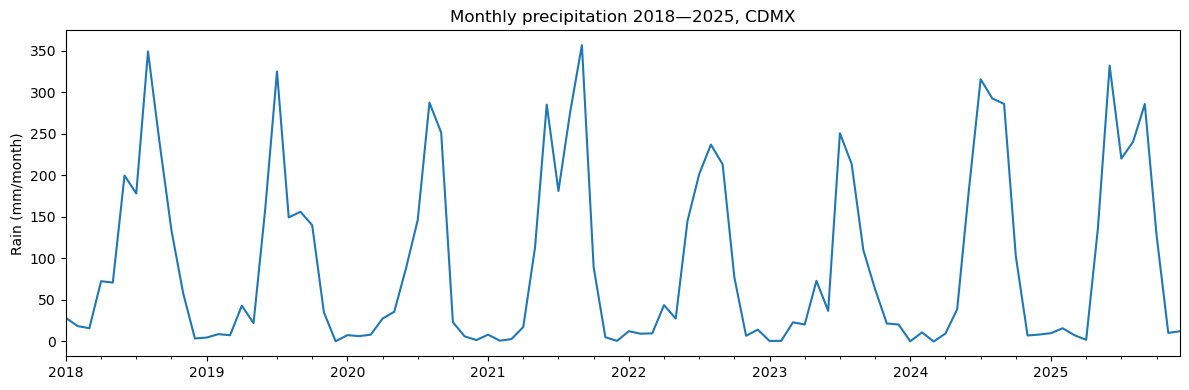

In [35]:
weather.set_index("datetime_hour")["rain"].resample("ME").sum().plot(figsize=(12, 4))
plt.title("Monthly precipitation 2018—2025, CDMX")
plt.ylabel("Rain (mm/month)")
plt.xlabel("")
plt.tight_layout()
plt.show()

In [40]:
# create a binary on whether it is raining or not, simplifying
weather["is_raining"] = (weather["rain"] > 0).astype(int)

,datetime_hour,temperature,rain,is_raining
0,2018-01-01 00:00:00,13.2,0.0,0
1,2018-01-01 01:00:00,12.1,0.0,0
2,2018-01-01 02:00:00,11.0,0.0,0
3,2018-01-01 03:00:00,10.1,0.0,0
4,2018-01-01 04:00:00,9.2,0.0,0


In [41]:
# Save to references for modeling
weather_path = REF_DIR / "weather_hourly_cdmx_2018_2025.parquet"
weather.to_parquet(weather_path, index=False)

print("Saved:", weather_path.resolve())


Saved: /Users/francobastida/Desktop/ecobici/data/reference/weather_hourly_cdmx_2018_2025.parquet


In [45]:
# Merge test

station_hour_path = Path("../outputs/ecobici_station_hour.parquet")

df = pd.read_parquet(station_hour_path)

df["datetime_hour"] = pd.to_datetime(df["datetime_hour"]).dt.floor("h")
weather["datetime_hour"] = pd.to_datetime(weather["datetime_hour"]).dt.floor("h")

test_merge = df[["station_id", "datetime_hour", "departures"]].head(100_000).merge(
    weather,
    on="datetime_hour",
    how="left"
)

test_merge.head()

,station_id,datetime_hour,departures,temperature,rain,is_raining
0,1,2018-01-01,0,13.2,0.0,0
1,6,2018-01-01,3,13.2,0.0,0
2,9,2018-01-01,1,13.2,0.0,0
3,16,2018-01-01,7,13.2,0.0,0
4,18,2018-01-01,14,13.2,0.0,0
